In [2]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import accuracy_score
import torch
import torch.nn as nn

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"
column_names = [
    'age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg',
    'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'
]
data = pd.read_csv(url, names=column_names)

# Replace missing values marked by '?' with NaN
data.replace('?', np.nan, inplace=True)

# Drop rows with missing values
data.dropna(inplace=True)

# Convert columns to appropriate data types
data = data.astype(float)

# Convert the target variable to binary classification
data['target'] = data['target'].apply(lambda x: 1 if x > 0 else 0)

# Split the dataset into features and target
X = data.drop('target', axis=1)
y = data['target']

# Standardize the features
scaler = StandardScaler() #MinMaxScaler()
X = scaler.fit_transform(X)

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 2: Hypervector Generation
def generate_hypervector(size, seed=None):
    if seed is not None:
        np.random.seed(seed)
    return np.random.choice([-1, 1], size)

# Parameters
dim = 10000  # Dimension of hypervectors

# Generate random hypervectors for each feature
feature_hvs = [generate_hypervector(dim, seed=i) for i in range(X.shape[1])]

# Function to encode a data point into a hypervector
def encode_hypervector(data_point, feature_hvs):
    hypervector = np.zeros(dim)
    for i, value in enumerate(data_point):
        hypervector += value * feature_hvs[i]
    return np.sign(hypervector)

# Encode training and testing data
X_train_hv = np.array([encode_hypervector(x, feature_hvs) for x in X_train])
X_test_hv = np.array([encode_hypervector(x, feature_hvs) for x in X_test])

# Step 3: Model Training
class HDClassifier(nn.Module):
    def __init__(self, input_dim):
        super(HDClassifier, self).__init__()
        self.fc = nn.Linear(input_dim, 1)
    
    def forward(self, x):
        return torch.sigmoid(self.fc(x))

# Convert hypervectors to PyTorch tensors
X_train_hv_tensor = torch.tensor(X_train_hv, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
X_test_hv_tensor = torch.tensor(X_test_hv, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

# Initialize the model, loss function, and optimizer
model = HDClassifier(dim)
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

# Training loop
num_epochs = 200
for epoch in range(num_epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(X_train_hv_tensor)
    loss = criterion(outputs, y_train_tensor)
    loss.backward()
    optimizer.step()
    
    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')

# Step 4: Evaluation
model.eval()
with torch.no_grad():
    y_pred_train = model(X_train_hv_tensor).round()
    y_pred_test = model(X_test_hv_tensor).round()
    
    train_accuracy = accuracy_score(y_train, y_pred_train)
    test_accuracy = accuracy_score(y_test, y_pred_test)
    
    print(f'Training Accuracy: {train_accuracy:.4f}')
    print(f'Test Accuracy: {test_accuracy:.4f}')

Epoch [10/200], Loss: 0.3839
Epoch [20/200], Loss: 0.3412
Epoch [30/200], Loss: 0.3018
Epoch [40/200], Loss: 0.2646
Epoch [50/200], Loss: 0.2317
Epoch [60/200], Loss: 0.2044
Epoch [70/200], Loss: 0.1809
Epoch [80/200], Loss: 0.1604
Epoch [90/200], Loss: 0.1427
Epoch [100/200], Loss: 0.1273
Epoch [110/200], Loss: 0.1141
Epoch [120/200], Loss: 0.1027
Epoch [130/200], Loss: 0.0928
Epoch [140/200], Loss: 0.0843
Epoch [150/200], Loss: 0.0769
Epoch [160/200], Loss: 0.0704
Epoch [170/200], Loss: 0.0648
Epoch [180/200], Loss: 0.0598
Epoch [190/200], Loss: 0.0554
Epoch [200/200], Loss: 0.0514
Training Accuracy: 1.0000
Test Accuracy: 0.8667


In [8]:
X_train_hv_tensor

tensor([[ 1., -1., -1.,  ..., -1., -1., -1.],
        [-1., -1.,  1.,  ..., -1.,  1., -1.],
        [-1., -1., -1.,  ..., -1.,  1., -1.],
        ...,
        [ 1.,  1., -1.,  ...,  1., -1.,  1.],
        [ 1., -1., -1.,  ..., -1., -1., -1.],
        [-1.,  1.,  1.,  ..., -1.,  1., -1.]])

Epoch [10/200], Loss: 0.3720, Train Accuracy: 0.8270, Test Accuracy: 0.8833
Epoch [20/200], Loss: 0.3226, Train Accuracy: 0.8608, Test Accuracy: 0.8500
Epoch [30/200], Loss: 0.2809, Train Accuracy: 0.8861, Test Accuracy: 0.7667
Epoch [40/200], Loss: 0.2400, Train Accuracy: 0.9156, Test Accuracy: 0.8000
Epoch [50/200], Loss: 0.2063, Train Accuracy: 0.9536, Test Accuracy: 0.8333
Epoch [60/200], Loss: 0.1789, Train Accuracy: 0.9662, Test Accuracy: 0.8333
Epoch [70/200], Loss: 0.1555, Train Accuracy: 0.9662, Test Accuracy: 0.8167
Epoch [80/200], Loss: 0.1359, Train Accuracy: 0.9789, Test Accuracy: 0.8333
Epoch [90/200], Loss: 0.1194, Train Accuracy: 0.9831, Test Accuracy: 0.8500
Epoch [100/200], Loss: 0.1056, Train Accuracy: 0.9873, Test Accuracy: 0.8500
Epoch [110/200], Loss: 0.0940, Train Accuracy: 0.9958, Test Accuracy: 0.8500
Epoch [120/200], Loss: 0.0842, Train Accuracy: 1.0000, Test Accuracy: 0.8500
Epoch [130/200], Loss: 0.0758, Train Accuracy: 1.0000, Test Accuracy: 0.8500
Epoch [1

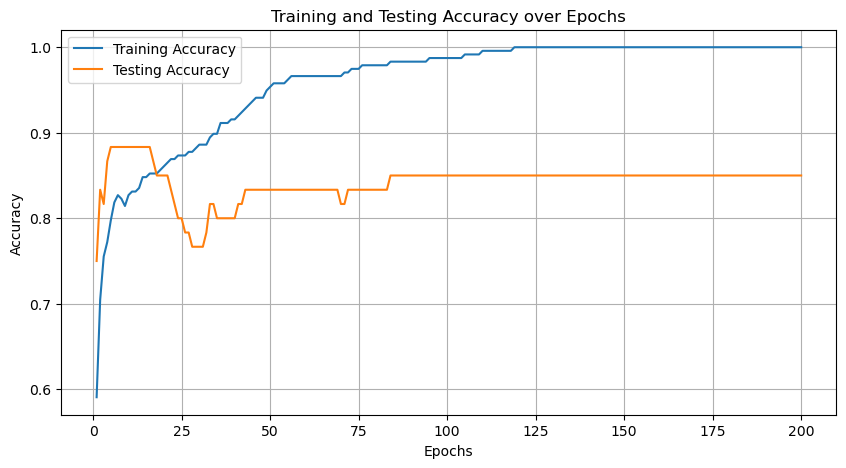

In [3]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"
column_names = [
    'age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg',
    'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'
]
data = pd.read_csv(url, names=column_names)

# Replace missing values marked by '?' with NaN
data.replace('?', np.nan, inplace=True)

# Drop rows with missing values
data.dropna(inplace=True)

# Convert columns to appropriate data types
data = data.astype(float)

# Convert the target variable to binary classification
data['target'] = data['target'].apply(lambda x: 1 if x > 0 else 0)

# Split the dataset into features and target
X = data.drop('target', axis=1)
y = data['target']

# Standardize the features
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 2: Hypervector Generation
def generate_hypervector(size, seed=None):
    if seed is not None:
        np.random.seed(seed)
    return np.random.choice([-1, 1], size)

# Parameters
dim = 10000  # Dimension of hypervectors

# Generate random hypervectors for each feature
feature_hvs = [generate_hypervector(dim, seed=i) for i in range(X.shape[1])]

# Function to encode a data point into a hypervector
def encode_hypervector(data_point, feature_hvs):
    hypervector = np.zeros(dim)
    for i, value in enumerate(data_point):
        hypervector += value * feature_hvs[i]
    return np.sign(hypervector)

# Encode training and testing data
X_train_hv = np.array([encode_hypervector(x, feature_hvs) for x in X_train])
X_test_hv = np.array([encode_hypervector(x, feature_hvs) for x in X_test])

# Step 3: Model Training
class HDClassifier(nn.Module):
    def __init__(self, input_dim):
        super(HDClassifier, self).__init__()
        self.fc = nn.Linear(input_dim, 1)
    
    def forward(self, x):
        return torch.sigmoid(self.fc(x))

# Convert hypervectors to PyTorch tensors
X_train_hv_tensor = torch.tensor(X_train_hv, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
X_test_hv_tensor = torch.tensor(X_test_hv, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

# Initialize the model, loss function, and optimizer
model = HDClassifier(dim)
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

# Initialize lists to store accuracy values
train_accuracies = []
test_accuracies = []

# Training loop
num_epochs = 200
for epoch in range(num_epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(X_train_hv_tensor)
    loss = criterion(outputs, y_train_tensor)
    loss.backward()
    optimizer.step()
    
    # Calculate accuracy
    with torch.no_grad():
        y_pred_train = outputs.round()
        train_accuracy = accuracy_score(y_train, y_pred_train)
        y_pred_test = model(X_test_hv_tensor).round()
        test_accuracy = accuracy_score(y_test, y_pred_test)
    
    train_accuracies.append(train_accuracy)
    test_accuracies.append(test_accuracy)

    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}, Train Accuracy: {train_accuracy:.4f}, Test Accuracy: {test_accuracy:.4f}')

# Step 4: Evaluation
model.eval()
with torch.no_grad():
    y_pred_train = model(X_train_hv_tensor).round()
    y_pred_test = model(X_test_hv_tensor).round()
    
    train_accuracy = accuracy_score(y_train, y_pred_train)
    test_accuracy = accuracy_score(y_test, y_pred_test)
    
    print(f'Training Accuracy: {train_accuracy:.4f}')
    print(f'Test Accuracy: {test_accuracy:.4f}')

# Plot the accuracies
plt.figure(figsize=(10, 5))
plt.plot(range(1, num_epochs + 1), train_accuracies, label='Training Accuracy')
plt.plot(range(1, num_epochs + 1), test_accuracies, label='Testing Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Testing Accuracy over Epochs')
plt.legend()
plt.grid()
plt.show()

Epoch [10/100], Loss: 0.0442, Train Accuracy: 1.0000, Test Accuracy: 0.8833
Epoch [20/100], Loss: 0.0097, Train Accuracy: 1.0000, Test Accuracy: 0.8833
Epoch [30/100], Loss: 0.0043, Train Accuracy: 1.0000, Test Accuracy: 0.8500
Epoch [40/100], Loss: 0.0026, Train Accuracy: 1.0000, Test Accuracy: 0.8667
Epoch [50/100], Loss: 0.0020, Train Accuracy: 1.0000, Test Accuracy: 0.8667
Epoch [60/100], Loss: 0.0016, Train Accuracy: 1.0000, Test Accuracy: 0.8667
Epoch [70/100], Loss: 0.0014, Train Accuracy: 1.0000, Test Accuracy: 0.8667
Epoch [80/100], Loss: 0.0012, Train Accuracy: 1.0000, Test Accuracy: 0.8667
Epoch [90/100], Loss: 0.0011, Train Accuracy: 1.0000, Test Accuracy: 0.8667
Epoch [100/100], Loss: 0.0010, Train Accuracy: 1.0000, Test Accuracy: 0.8667
Training Accuracy: 1.0000
Test Accuracy: 0.8500


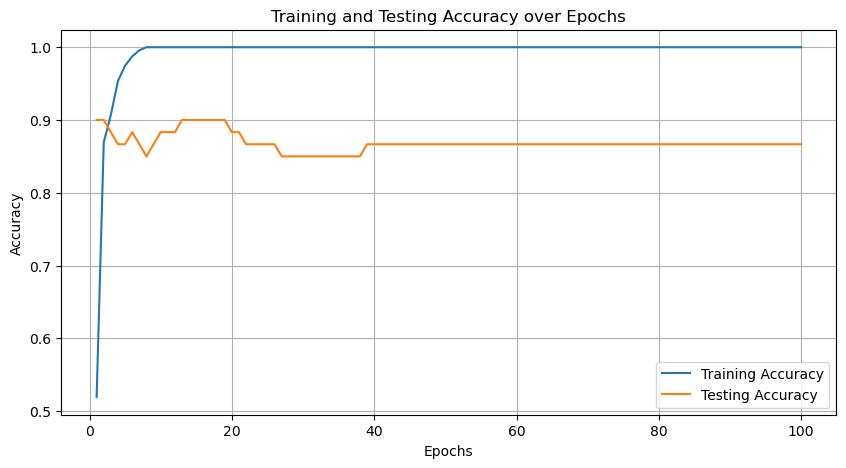

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"
column_names = [
    'age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg',
    'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'
]
data = pd.read_csv(url, names=column_names)

# Replace missing values marked by '?' with NaN
data.replace('?', np.nan, inplace=True)

# Drop rows with missing values
data.dropna(inplace=True)

# Convert columns to appropriate data types
data = data.astype(float)

# Convert the target variable to binary classification
data['target'] = data['target'].apply(lambda x: 1 if x > 0 else 0)

# Split the dataset into features and target
X = data.drop('target', axis=1)
y = data['target']

# Standardize the features
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 2: Hypervector Generation
def generate_hypervector(size, seed=None):
    if seed is not None:
        np.random.seed(seed)
    return np.random.choice([-1, 1], size)

# Parameters
dim = 10000  # Dimension of hypervectors

# Generate random hypervectors for each feature
feature_hvs = [generate_hypervector(dim, seed=i) for i in range(X.shape[1])]

# Function to encode a data point into a hypervector
def encode_hypervector(data_point, feature_hvs):
    hypervector = np.zeros(dim)
    for i, value in enumerate(data_point):
        hypervector += value * feature_hvs[i]
    return np.sign(hypervector)

# Encode training and testing data
X_train_hv = np.array([encode_hypervector(x, feature_hvs) for x in X_train])
X_test_hv = np.array([encode_hypervector(x, feature_hvs) for x in X_test])

# Step 3: Model Training
class HDClassifier(nn.Module):
    def __init__(self, input_dim):
        super(HDClassifier, self).__init__()
        self.fc1 = nn.Linear(input_dim, 2048)
        self.bn1 = nn.BatchNorm1d(2048)
        self.fc2 = nn.Linear(2048, 1024)
        self.bn2 = nn.BatchNorm1d(1024)
        self.fc3 = nn.Linear(1024, 1)

    def forward(self, x):
        x = torch.relu(self.bn1(self.fc1(x)))
        x = torch.relu(self.bn2(self.fc2(x)))
        return torch.sigmoid(self.fc3(x))

# Convert hypervectors to PyTorch tensors
X_train_hv_tensor = torch.tensor(X_train_hv, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
X_test_hv_tensor = torch.tensor(X_test_hv, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

# Initialize the model, loss function, and optimizer
model = HDClassifier(dim)
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

# Initialize lists to store accuracy values
train_accuracies = []
test_accuracies = []

# Training loop
num_epochs = 100  # Increased epochs
for epoch in range(num_epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(X_train_hv_tensor)
    loss = criterion(outputs, y_train_tensor)
    loss.backward()
    optimizer.step()
    
    # Calculate accuracy
    with torch.no_grad():
        y_pred_train = outputs.round()
        train_accuracy = accuracy_score(y_train, y_pred_train)
        y_pred_test = model(X_test_hv_tensor).round()
        test_accuracy = accuracy_score(y_test, y_pred_test)
    
    train_accuracies.append(train_accuracy)
    test_accuracies.append(test_accuracy)

    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}, Train Accuracy: {train_accuracy:.4f}, Test Accuracy: {test_accuracy:.4f}')

# Step 4: Evaluation
model.eval()
with torch.no_grad():
    y_pred_train = model(X_train_hv_tensor).round()
    y_pred_test = model(X_test_hv_tensor).round()
    
    train_accuracy = accuracy_score(y_train, y_pred_train)
    test_accuracy = accuracy_score(y_test, y_pred_test)
    
    print(f'Training Accuracy: {train_accuracy:.4f}')
    print(f'Test Accuracy: {test_accuracy:.4f}')

# Plot the accuracies
plt.figure(figsize=(10, 5))
plt.plot(range(1, num_epochs + 1), train_accuracies, label='Training Accuracy')
plt.plot(range(1, num_epochs + 1), test_accuracies, label='Testing Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Testing Accuracy over Epochs')
plt.legend()
plt.grid()
plt.show()